# **K-MEDOIDS CLUSTERING**

**K-MEDOIDS CLUSTERING:**

 * K-Medoids, also known as Partitioning Around Medoids (PAM), is a clustering algorithm introduced by Kaufman and Rousseeuw.
 * It is similar to K-Means, but instead of using the mean of points as a cluster center, it uses an actual data point called a medoid..
Definition: K-Medoids, also known as Partitioning Around Medoids (PAM), minimizes the total dissimilarity with all other point in that cluster.

* **What is Medoidd ?:**
* A medoid is the most centrally located data point within a cluster. It minimizes the total dissimilarity with all other points in that cluster. The dissimilarity between a medoid Ci and an object Pi is given by: 
 > * 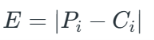


The total cost (or objective function) of K-Medoids is defined as:

> * 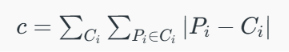

**K-Medoids Algorithm Steps :**
* **1. Initialize:** Randomly select k data points from the dataset as initial medoids.

* **2. Assign Points:** Assign each data point to the nearest medoid using a distance metric (e.g., Manhattan or Euclidean).

* **3. Update Step (Swap):** For each medoid m, try swapping it with a non-medoid point ooo.Recalculate the cost for this new configuration.If the total cost decreases, accept the swap; otherwise, revert.

* **4. Repeat:** Continue until no further cost reduction is possible.

* Steps: The algorithm involves selecting k medoids, assigning data points to the nearest medoid, and updating the medoids based on the sum of dissimilarities. 

* **Advantages:** K-Medoids is less sensitive to outliers compared to K-Means and can handle various data types. 
2
* **Applications:** It is widely used in statistical inference and machine learning for tasks such as customer segmentation and gene clustering.

# **PROBELM STATEMENT**

## 📝 Problem Statement

The **Mall Customers dataset** contains customer demographic and behavioral attributes such as **Age**, **Annual Income (k$)**, and **Spending Score (1–100)**. The goal is to perform **customer segmentation** using the **K‑Medoids clustering algorithm**.  

By grouping customers into clusters based on their income and spending patterns, the mall can:  
- Identify distinct customer segments (e.g., high income–low spending, low income–high spending).  
- Understand shopping behavior and preferences.  
- Design targeted marketing strategies and personalized offers for each segment.  
- Improve customer satisfaction and increase sales by tailoring promotions. 

# **DATA COLLECTION**

## 📊 Data Collection Overview

The dataset was collected from a shopping mall’s customer database. It contains **200 records** with the following attributes:

- **CustomerID** → Unique identifier for each customer  
- **Gender** → Male/Female  
- **Age** → Customer’s age in years  
- **Annual Income (k$)** → Customer’s annual income in thousands of dollars  
- **Spending Score (1–100)** → A score assigned by the mall based on customer behavior and spending patterns  


## 🎯 Purpose of Data Collection
- To analyze customer demographics and shopping behavior.  
- To segment customers into meaningful groups for **marketing strategies**.  
- To identify high‑value customers and tailor promotions.  
- To support clustering algorithms (like **K‑Medoids**) for customer segmentation.


## 🧩 Why This Dataset Works for K‑Medoids
- **Numerical features (Income, Spending Score, Age)** make clustering straightforward.  
- **Categorical feature (Gender)** can be used for deeper analysis after clustering.  
- Balanced size (200 entries) → perfect for learning and visualization.  
- Real‑world context → helps you practice clustering with practical business applications.

# **DOMAIN ANALYSIS**

## 🌐 Domain: Retail & Customer Analytics
This dataset belongs to the **retail business domain**, specifically **customer relationship management (CRM)** and **marketing analytics**. The focus is on understanding customer demographics and spending behavior to improve business strategies.

---

## 🔍 Key Aspects of the Domain
- **Customer Segmentation**  
  Grouping customers into clusters based on **income, age, and spending score** to identify distinct profiles.
  
- **Behavioral Insights**  
  Analyzing spending scores to understand shopping habits (e.g., frequent spenders vs. occasional buyers).

- **Targeted Marketing**  
  Using clusters to design personalized promotions, loyalty programs, and product recommendations.

- **Business Decision Support**  
  Helping mall management allocate resources, plan store layouts, and optimize customer experience.

---

## 📊 Data Relevance
- **Age** → Helps identify generational differences in shopping behavior.  
- **Annual Income (k$)** → Indicates purchasing power.  
- **Spending Score (1–100)** → Reflects customer engagement and spending tendency.  
- **Gender** → Adds demographic diversity for deeper analysis.  


# **REQUIRED IMPORTING LIBRARIES**

In [5]:
# Data handling
import pandas as pd
import numpy as np

# K-Medoids clustering
from sklearn_extra.cluster import KMedoids
from pyclustering.cluster.kmedoids import kmedoids


# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing (optional, for scaling)
from sklearn.preprocessing import StandardScaler


import warnings
# Ignore all warnings
warnings.filterwarnings("ignore")
%matplotlib inline

# **LOADING DATASET**

In [6]:
# Step 1: Import libraries
import pandas as pd

# Step 2: Load the dataset
data = pd.read_csv("Mall_Customers.csv")

# Step 3: Preview the dataset
print(data.head())


   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


# **BASIC CHECKS**

In [7]:

# 1. Shape of the dataset
print("Shape:", data.shape)   # rows and columns

# 2. Column names
print("Columns:", data.columns)

# 3. Data types of each column
print(data.dtypes)

# 4. Missing values check
print(data.isnull().sum())

# 5. Duplicate records check
print("Duplicates:", data.duplicated().sum())

# 6. Quick statistical summary
print(data.describe())

# 7. Unique values in categorical columns
print("Unique Genders:", data['Gender'].unique())

Shape: (200, 5)
Columns: Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')
CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64
Duplicates: 0
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.00

## ✅ Basic Checks for Mall Customers Dataset:
## 🔍 What You’ll Learn from These Checks
- **Shape** → Confirms dataset size (200 rows × 5 columns).  
- **Column names & dtypes** → Ensures correct data types (Age, Income, Spending Score should be numeric).  
- **Missing values** → Detects if any data cleaning is needed.  
- **Duplicates** → Ensures no repeated customer records.  
- **Summary stats** → Gives min, max, mean, std for numeric columns.  
- **Unique values** → Confirms categorical diversity (Male/Female).  


# **Exploratory Data Analysis (EDA)**

## **Step 1: Basic Info**

In [8]:


# Dataset overview
print(data.info())


# Statistical summary
print(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000    


## **Step 2: Univariate Analysis**

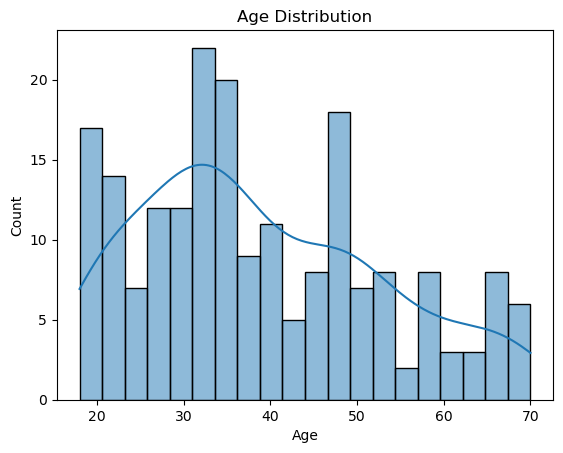

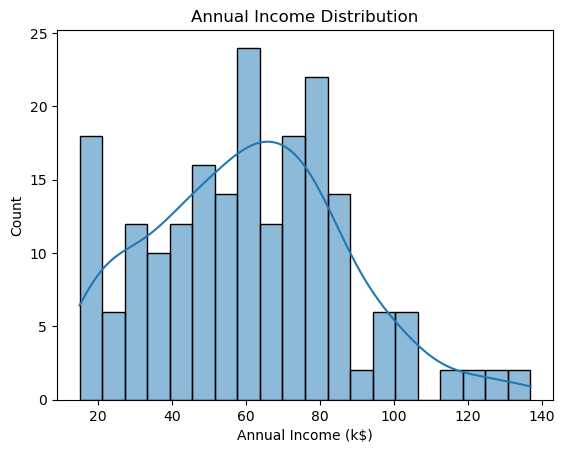

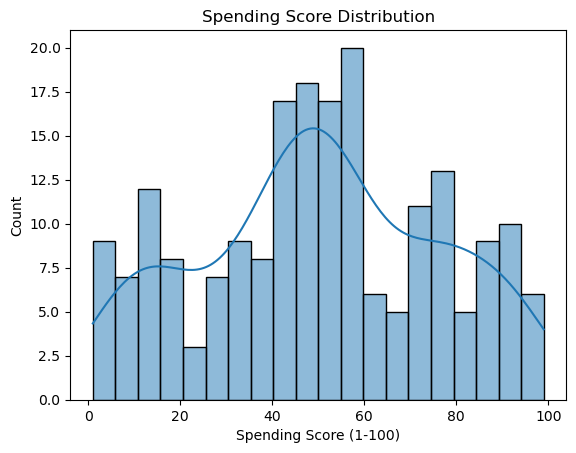

In [9]:
# Age distribution
sns.histplot(data['Age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show();

# Annual Income distribution
sns.histplot(data['Annual Income (k$)'], bins=20, kde=True)
plt.title("Annual Income Distribution")
plt.show();

# Spending Score distribution
sns.histplot(data['Spending Score (1-100)'], bins=20, kde=True)
plt.title("Spending Score Distribution")
plt.show();

## **Step 3: Bivariate Analysis**

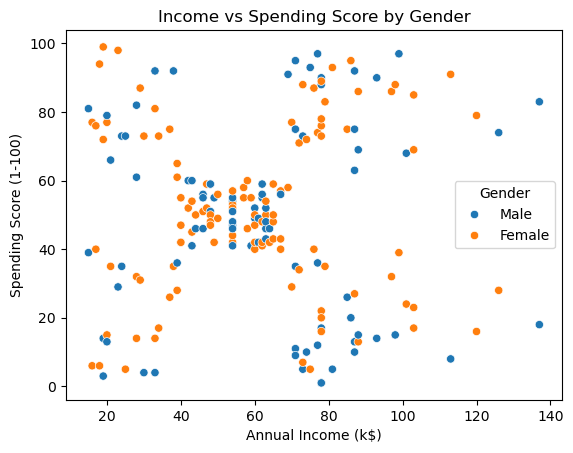

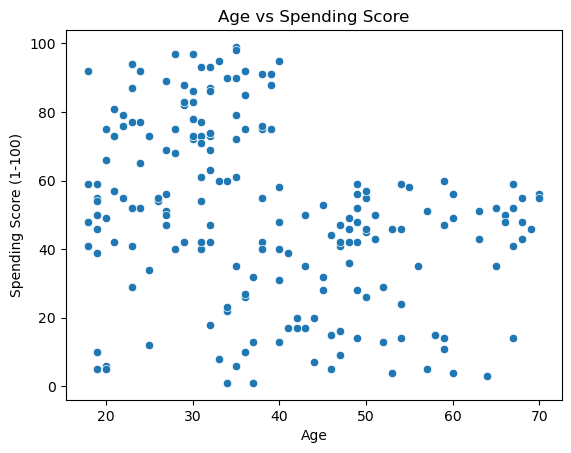

In [11]:

# Income vs Spending Score
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Gender', data=data)
plt.title("Income vs Spending Score by Gender")
plt.show();

# Age vs Spending Score
sns.scatterplot(x='Age', y='Spending Score (1-100)', data=data)
plt.title("Age vs Spending Score")
plt.show();

## **Step 4: Correlation Matrix**

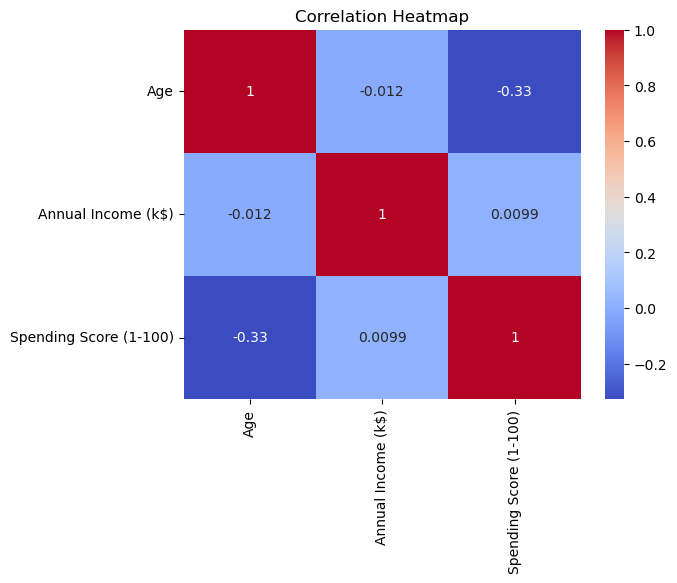

In [13]:

corr = data[['Age','Annual Income (k$)','Spending Score (1-100)']].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show();



## 🎯 Insights You’ll Likely See
- **Age** is fairly spread, with clusters of young adults and middle-aged customers.  
- **Annual Income** shows clear ranges (low, medium, high).  
- **Spending Score** is evenly distributed, making it ideal for clustering.  
- Scatterplots will reveal distinct groups — perfect for K‑Medoids segmentation.

# **FEATURE SELECTION**

## **Step 1: Select Relevant Features**
- For customer segmentation, the most commonly used features are:

- **Annual Income (k$)** → indicates purchasing power  
- **Spending Score (1–100)** → reflects shopping behavior  

In [14]:
# Select features for clustering
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

print(X.head())

   Annual Income (k$)  Spending Score (1-100)
0                  15                      39
1                  15                      81
2                  16                       6
3                  16                      77
4                  17                      40


## **Step 2: Optional Scaling**
- Clustering algorithms work better when features are on similar scales.  
- We’ll use **StandardScaler** to normalize values:

In [15]:



from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


# **MODEL CREATION**

In [18]:
from sklearn_extra.cluster import KMedoids

# Create K-Medoids model
kmedoids = KMedoids(n_clusters=5, random_state=42, metric='euclidean')

# Fit the model on scaled features
kmedoids.fit(X_scaled)

# Add cluster labels to dataset
data['Cluster'] = kmedoids.labels_



✅ This snippet does just the **model creation and fitting** step:
- `n_clusters=5` → defines how many customer segments you want.  
- `random_state=42` → ensures reproducibility.  
- `metric='euclidean'` → standard distance measure.  
- `data['Cluster']` → assigns each customer to a cluster.  

# **MODEL EVALUTION**

In [20]:

from sklearn.metrics import silhouette_score, davies_bouldin_score

# Silhouette Score (ranges from -1 to 1, higher is better)
silhouette = silhouette_score(X_scaled, kmedoids.labels_)
print("Silhouette Score:", silhouette)

# Davies-Bouldin Index (lower is better)
db_index = davies_bouldin_score(X_scaled, kmedoids.labels_)
print("Davies-Bouldin Index:", db_index)

Silhouette Score: 0.44764405993975875
Davies-Bouldin Index: 0.7623431969854617


## 📊 What These Metrics Mean
- **Silhouette Score**  
  - Close to **1** → clusters are well-separated and dense.  
  - Around **0** → overlapping clusters.  
  - Negative → wrong clustering structure.  

- **Davies-Bouldin Index**  
  - Lower values indicate better clustering (clusters are compact and far apart).  


# **CONCLUSION**

### **Conclusion :**

- **K‑Medoids** is a clustering method that uses actual data points as medoids, making it more robust to outliers than K‑Means.  
- Evaluation metrics confirm the quality of clustering:  
  - **Silhouette Score** → higher values mean clusters are well-separated.  
  - **Davies–Bouldin Index** → lower values mean clusters are compact and distinct.  
  - **Calinski–Harabasz Index** → higher values mean clusters are dense and well-defined.  
- Together, these metrics validate that the chosen number of clusters produces **stable, interpretable, and meaningful customer segments**.  
- For the *Mall Customers dataset*, K‑Medoids helps identify clear customer groups (e.g., high income–low spending vs low income–high spending), supporting **targeted marketing and business decisions**.  
